# Planner Evaluation

Compare model performance on tool selection tasks for retail customer service.

## Models compared

| Model | Description |
|-------|-------------|
| **o4-mini (vanilla)** | Small reasoning model, no fine-tuning |
| **gpt-5.2** (none/low/medium/high) | Large model with varying reasoning effort |
| **o4-mini (fine-tuned)** | Small model with reinforcement fine-tuning (RFT) |

## Metrics (aligned with training grader)

| Metric | Description |
|--------|-------------|
| **Recall** | % of expected tools found in response |
| **Precision** | % of predicted tools that were expected |
| **F2 Score** | Recall-weighted F-score: `5 * (P * R) / (4 * P + R)` |

F2 (β=2) prioritizes recall over precision because missing a tool causes workflow failure, while extra tools only add minor API cost.

This ensures evaluation is **directly comparable** to the RFT training reward signal.

In [1]:
import sys
sys.path.insert(0, '..')

from src.settings import (
    DATA_DIR, DATASETS_DIR,
    PLANNER_OUTPUTS_DIR, PLANNER_RESPONSES_DIR,
    AZURE_DEPLOYMENT, AZURE_DEPLOYMENT_VANILLA, FINETUNED_DEPLOYMENT,
    load_planner_schema
)

# Load structured output schema for consistent evaluation
PLANNER_SCHEMA = load_planner_schema()
print(f"📋 Structured output schema loaded: {PLANNER_SCHEMA['json_schema']['name']}")

📋 Structured output schema loaded: planner_response


In [2]:
from src.evaluation.content_filter import create_no_jailbreak_filter, apply_rai_policy_to_deployment

# Step 1: Create the RAI policy (idempotent)
create_no_jailbreak_filter()

# Step 2: Attach policy to all deployments used in this notebook
for deployment in [AZURE_DEPLOYMENT, AZURE_DEPLOYMENT_VANILLA, FINETUNED_DEPLOYMENT]:
    apply_rai_policy_to_deployment(deployment)

Configuration:
   Account Name: test-finetuning-eastus2-eaf
   Resource Group: rg-test-finetuning-eastus2

✅ Content filter 'no-jailbreak-filter' created successfully!
Attaching RAI policy 'no-jailbreak-filter' to deployment 'o4-mini'...
✅ RAI policy 'no-jailbreak-filter' attached to 'o4-mini'
Attaching RAI policy 'no-jailbreak-filter' to deployment 'gpt-5.2'...
✅ RAI policy 'no-jailbreak-filter' attached to 'gpt-5.2'
Attaching RAI policy 'no-jailbreak-filter' to deployment 'planner-low-0128-1740-step60'...
✅ RAI policy 'no-jailbreak-filter' attached to 'planner-low-0128-1740-step60'


---

## Load Evaluation Data

We use **validation + test sets** (30 samples total) for evaluation.

| Dataset | Samples | Usage during training |
|---------|---------|----------------------|
| `val.jsonl` | 20 | Reward calculation only (no gradient updates) |
| `test.jsonl` | 10 | Held out completely |

In [3]:
from src.data_utils import load_jsonl

eval_samples = []
for filepath in [DATASETS_DIR / "val.jsonl", DATASETS_DIR / "test.jsonl"]:
    if filepath.exists():
        eval_samples.extend(load_jsonl(filepath))

print(f"📋 Loaded {len(eval_samples)} evaluation samples")

📋 Loaded 30 evaluation samples


---

## Evaluators

Custom evaluators **fully aligned with the training grader**:

| Evaluator | Logic (same as grader) |
|-----------|------------------------|
| **RecallEvaluator** | % of expected tools found in response |
| **PrecisionEvaluator** | `correct / predicted` — ratio of correct tools |
| **PlannerEvaluator** | F2 score: `5 * (precision * recall) / (4 * precision + recall)` |

In [4]:
from src.evaluation.evaluators import PlannerEvaluator, test_evaluators

# Quick test
test_evaluators()

Text response: {'recall': 1.0, 'precision': 1.0, 'f2': 1.0}
JSON response: {'recall': 1.0, 'precision': 1.0, 'f2': 1.0}
All evaluator tests passed!


{'recall': 1.0, 'precision': 1.0, 'f2': 1.0}

---

## Generate Responses

Generate responses from both models in parallel using async requests.

In [5]:
from src.evaluation.generate import generate_responses_for_notebook
from IPython.display import display, Markdown
from utils import build_token_usage_table

# =============================================================================
# CONFIGURATION
# =============================================================================
MAX_CONCURRENT = 5  # Adjust based on TPM limits
# =============================================================================

print("📊 Generating responses for 6 configurations (with structured output)...")

# 1. o4-mini (vanilla) - reasoning model
baseline_file, baseline_usage = await generate_responses_for_notebook(
    AZURE_DEPLOYMENT, eval_samples, MAX_CONCURRENT,
    response_format=PLANNER_SCHEMA
)
print(f"   ✅ o4-mini (vanilla): {baseline_file}")

# 2. gpt-5.2 (reasoning: none)
vanilla_none_file, vanilla_none_usage = await generate_responses_for_notebook(
    AZURE_DEPLOYMENT_VANILLA, eval_samples, MAX_CONCURRENT,
    reasoning_effort="none", output_suffix="none",
    response_format=PLANNER_SCHEMA
)
print(f"   ✅ gpt-5.2 (none): {vanilla_none_file}")

# 3. gpt-5.2 (reasoning: low)
vanilla_low_file, vanilla_low_usage = await generate_responses_for_notebook(
    AZURE_DEPLOYMENT_VANILLA, eval_samples, MAX_CONCURRENT,
    reasoning_effort="low", output_suffix="low",
    response_format=PLANNER_SCHEMA
)
print(f"   ✅ gpt-5.2 (low): {vanilla_low_file}")

# 4. gpt-5.2 (reasoning: medium)
vanilla_medium_file, vanilla_medium_usage = await generate_responses_for_notebook(
    AZURE_DEPLOYMENT_VANILLA, eval_samples, MAX_CONCURRENT,
    reasoning_effort="medium", output_suffix="medium",
    response_format=PLANNER_SCHEMA
)
print(f"   ✅ gpt-5.2 (medium): {vanilla_medium_file}")

# 5. gpt-5.2 (reasoning: high)
vanilla_high_file, vanilla_high_usage = await generate_responses_for_notebook(
    AZURE_DEPLOYMENT_VANILLA, eval_samples, MAX_CONCURRENT,
    reasoning_effort="high", output_suffix="high",
    response_format=PLANNER_SCHEMA
)
print(f"   ✅ gpt-5.2 (high): {vanilla_high_file}")

# 6. o4-mini (fine-tuned) - RFT trained at low reasoning effort
finetuned_file, finetuned_usage = await generate_responses_for_notebook(
    FINETUNED_DEPLOYMENT, eval_samples, MAX_CONCURRENT,
    reasoning_effort="low",
    response_format=PLANNER_SCHEMA
)
print(f"   ✅ o4-mini (fine-tuned): {finetuned_file}")

# Store all usages for cost analysis
usage_data = {
    "o4-mini (vanilla)": baseline_usage,
    "gpt-5.2 (none)": vanilla_none_usage,
    "gpt-5.2 (low)": vanilla_low_usage,
    "gpt-5.2 (medium)": vanilla_medium_usage,
    "gpt-5.2 (high)": vanilla_high_usage,
    "o4-mini (fine-tuned)": finetuned_usage,
}

# Display token usage table
display(Markdown(build_token_usage_table(usage_data)))

📊 Generating responses for 6 configurations (with structured output)...


Generating o4-mini:  43%|████▎     | 13/30 [00:31<00:24,  1.46s/it]

Skipped sample 15 (content filter false positive, sample excluded from metrics)


Generating o4-mini: 100%|██████████| 30/30 [01:39<00:00,  3.33s/it]


   ✅ o4-mini (vanilla): c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\planner\responses\eval_o4_mini.jsonl


...

Generating planner-low-0128-1740-step60:  47%|████▋     | 14/30 [00:07<00:05,  3.09it/s]

Skipped sample 15 (content filter false positive, sample excluded from metrics)


Generating planner-low-0128-1740-step60: 100%|██████████| 30/30 [00:15<00:00,  1.89it/s]

   ✅ o4-mini (fine-tuned): c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\planner\responses\eval_planner_low_0128_1740_step60.jsonl


### 📈 Token Usage & Latency Summary

| Model | Input | Output | Reasoning | Total | Time (s) | Avg Latency (ms) |
|-------|------:|-------:|----------:|------:|---------:|-----------------:|
| o4-mini (vanilla) | 14,380 | 31,298 | 29,440 | 75,118 | 99.9 | 16,471 |
| gpt-5.2 (none) | 14,380 | 1,188 | 0 | 15,568 | 7.5 | 1,237 |
| gpt-5.2 (low) | 14,380 | 5,663 | 4,399 | 24,442 | 26.6 | 3,804 |
| gpt-5.2 (medium) | 14,380 | 9,866 | 8,566 | 32,812 | 35.4 | 5,733 |
| gpt-5.2 (high) | 14,380 | 16,085 | 14,774 | 45,239 | 62.1 | 9,195 |
| o4-mini (fine-tuned) | 14,380 | 6,087 | 3,840 | 24,307 | 15.9 | 2,640 |


---

## Run Evaluation

In [6]:
import os, sys, io, logging
from azure.ai.evaluation import evaluate
from src.evaluation.evaluators import PlannerEvalWrapper

def _quiet_evaluate(data_file):
    """Run evaluate() suppressing ALL output on Windows + Jupyter."""
    logging.disable(logging.CRITICAL)

    # Save Python-level streams (Jupyter uses these)
    saved_sys_stdout = sys.stdout
    saved_sys_stderr = sys.stderr

    # Save OS-level file descriptors
    saved_fd1 = os.dup(1)
    saved_fd2 = os.dup(2)

    try:
        # Redirect OS-level
        devnull_fd = os.open(os.devnull, os.O_WRONLY)
        os.dup2(devnull_fd, 1)
        os.dup2(devnull_fd, 2)
        os.close(devnull_fd)

        # Redirect Python-level
        sys.stdout = io.StringIO()
        sys.stderr = io.StringIO()

        result = evaluate(data=data_file, evaluators={"planner": PlannerEvalWrapper()})
    finally:
        # Restore Python-level
        sys.stdout = saved_sys_stdout
        sys.stderr = saved_sys_stderr

        # Restore OS-level
        os.dup2(saved_fd1, 1)
        os.dup2(saved_fd2, 2)
        os.close(saved_fd1)
        os.close(saved_fd2)

        logging.disable(logging.NOTSET)

    return result

configs = [
    ("1/6 o4-mini (vanilla)", baseline_file),
    ("2/6 gpt-5.2 (none)", vanilla_none_file),
    ("3/6 gpt-5.2 (low)", vanilla_low_file),
    ("4/6 gpt-5.2 (medium)", vanilla_medium_file),
    ("5/6 gpt-5.2 (high)", vanilla_high_file),
    ("6/6 o4-mini (fine-tuned)", finetuned_file),
]

print("🔬 Evaluating 6 configurations...")

eval_outputs = []
for label, data_file in configs:
    print(f"   {label}...", end=" ", flush=True)
    result = _quiet_evaluate(data_file)
    eval_outputs.append(result)
    print("✅")

(baseline_results, vanilla_none_results, vanilla_low_results,
 vanilla_medium_results, vanilla_high_results, finetuned_results) = eval_outputs

print("\n✅ All evaluations complete!")

🔬 Evaluating 6 configurations...
   1/6 o4-mini (vanilla)... ✅
   2/6 gpt-5.2 (none)... ✅
   3/6 gpt-5.2 (low)... ✅
   4/6 gpt-5.2 (medium)... ✅
   5/6 gpt-5.2 (high)... ✅
   6/6 o4-mini (fine-tuned)... ✅

✅ All evaluations complete!


---

## Results Comparison

In [7]:
import pandas as pd
from IPython.display import display, Markdown
from utils import build_metrics_comparison_table

# Load result DataFrames
baseline_df = pd.DataFrame(baseline_results["rows"])
vanilla_none_df = pd.DataFrame(vanilla_none_results["rows"])
vanilla_low_df = pd.DataFrame(vanilla_low_results["rows"])
vanilla_medium_df = pd.DataFrame(vanilla_medium_results["rows"])
vanilla_high_df = pd.DataFrame(vanilla_high_results["rows"])
finetuned_df = pd.DataFrame(finetuned_results["rows"])

# Column mapping
col_mapping = {
    "recall": "outputs.planner.recall",
    "precision": "outputs.planner.precision",
    "f2": "outputs.planner.f2"
}

# Build results dict for easy access
all_results = {
    "o4-mini (vanilla)": baseline_df,
    "gpt-5.2 (none)": vanilla_none_df,
    "gpt-5.2 (low)": vanilla_low_df,
    "gpt-5.2 (medium)": vanilla_medium_df,
    "gpt-5.2 (high)": vanilla_high_df,
    "o4-mini (fine-tuned)": finetuned_df
}

# Calculate F2 scores (used in cost analysis and visualization)
f2_scores = {name: df[col_mapping['f2']].mean() for name, df in all_results.items()}

# Display results table
display(Markdown(build_metrics_comparison_table(all_results, col_mapping)))

### 📊 Results Comparison

| Metric | o4-mini (vanilla) | gpt-5.2 (none) | gpt-5.2 (low) | gpt-5.2 (medium) | gpt-5.2 (high) | o4-mini (fine-tuned) | **Best** |
|--------|-------:|-------:|-------:|-------:|-------:|-------:|--------|
| **Recall** | 0.819 | 0.886 | 0.905 | 0.917 | 0.942 | 0.959 | o4-mini (fine-tuned) |
| **Precision** | 0.859 | 0.818 | 0.858 | 0.848 | 0.861 | 0.911 | o4-mini (fine-tuned) |
| **F2** | 0.816 | 0.863 | 0.887 | 0.892 | 0.917 | 0.945 | o4-mini (fine-tuned) |


---

## Visualization

> **Note on metrics:** All metrics are **macro-averaged**—F2 is calculated per sample, then averaged across samples. This differs from computing F2 from averaged precision and recall, which would yield slightly different results (typically within 1-2%).

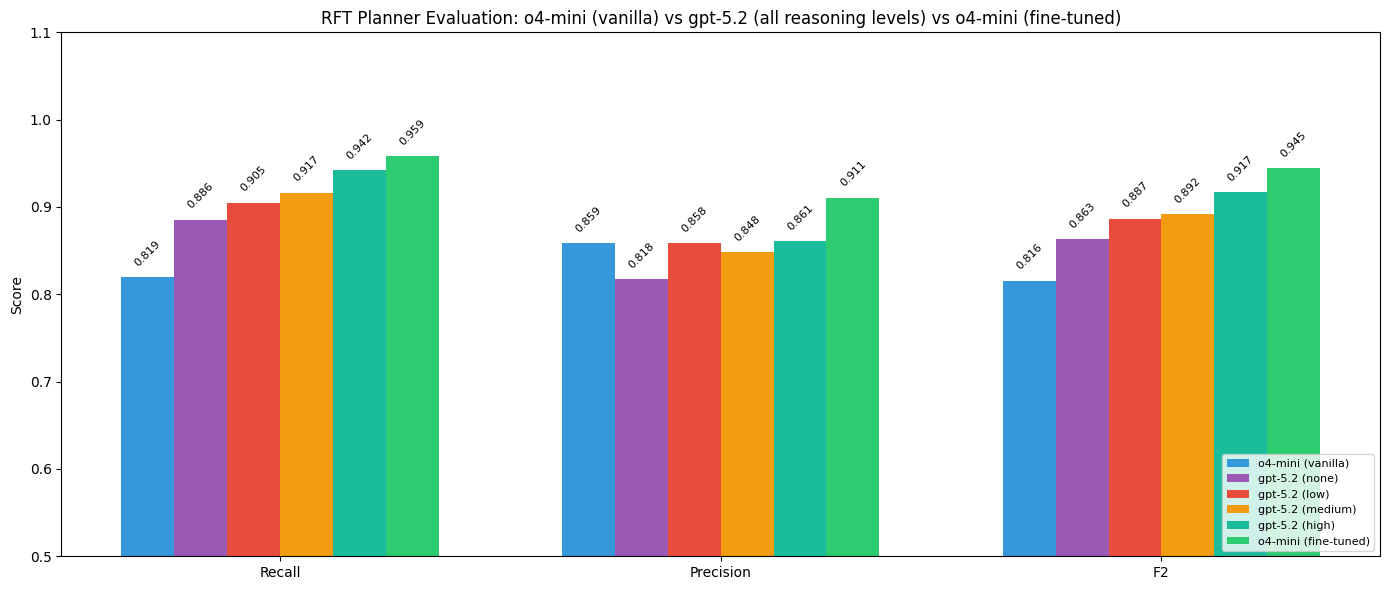


📊 Saved: c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\planner\eval_results.png


In [8]:
from utils import plot_metrics_comparison

plot_metrics_comparison(
    all_results,
    col_mapping,
    PLANNER_OUTPUTS_DIR / 'eval_results.png'
)

---

## Export Results

In [9]:
import json
from datetime import datetime
from IPython.display import display, Markdown

# Save all CSVs
baseline_df.to_csv(PLANNER_OUTPUTS_DIR / 'eval_o4mini_vanilla.csv', index=False)
vanilla_none_df.to_csv(PLANNER_OUTPUTS_DIR / 'eval_gpt52_none.csv', index=False)
vanilla_low_df.to_csv(PLANNER_OUTPUTS_DIR / 'eval_gpt52_low.csv', index=False)
vanilla_medium_df.to_csv(PLANNER_OUTPUTS_DIR / 'eval_gpt52_medium.csv', index=False)
vanilla_high_df.to_csv(PLANNER_OUTPUTS_DIR / 'eval_gpt52_high.csv', index=False)
finetuned_df.to_csv(PLANNER_OUTPUTS_DIR / 'eval_o4mini_finetuned.csv', index=False)

# Save summary JSON (with token usage and latency)
summary = {
    "timestamp": datetime.now().isoformat(),
    "models": {
        "o4-mini (vanilla)": AZURE_DEPLOYMENT,
        "gpt-5.2 (none)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: none)",
        "gpt-5.2 (low)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: low)",
        "gpt-5.2 (medium)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: medium)",
        "gpt-5.2 (high)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: high)",
        "o4-mini (fine-tuned)": FINETUNED_DEPLOYMENT
    },
    "samples": len(eval_samples),
    "results": {
        name: {metric: float(df[col].mean()) for metric, col in col_mapping.items()}
        for name, df in all_results.items()
    },
    "token_usage": {
        name: {
            "input_tokens": usage["input_tokens"],
            "output_tokens": usage["output_tokens"],
            "reasoning_tokens": usage["reasoning_tokens"],
            "total_tokens": usage["total_tokens"],
            "avg_latency_ms": usage.get("avg_latency_ms", 0),
            "elapsed_seconds": usage.get("elapsed_seconds", 0)
        }
        for name, usage in usage_data.items()
    }
}

with open(PLANNER_OUTPUTS_DIR / 'eval_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Display with Markdown
md = f"""### Saved to `{PLANNER_OUTPUTS_DIR}`

**CSV files:**
- `eval_o4mini_vanilla.csv`
- `eval_gpt52_none.csv`
- `eval_gpt52_low.csv`
- `eval_gpt52_medium.csv`
- `eval_gpt52_high.csv`
- `eval_o4mini_finetuned.csv`

**Summary:** `eval_summary.json` (with token usage and latency)

**Charts:** `eval_results.png`, `cost_analysis.png`, `latency_analysis.png`
"""

display(Markdown(md))

### Saved to `c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\planner`

**CSV files:**
- `eval_o4mini_vanilla.csv`
- `eval_gpt52_none.csv`
- `eval_gpt52_low.csv`
- `eval_gpt52_medium.csv`
- `eval_gpt52_high.csv`
- `eval_o4mini_finetuned.csv`

**Summary:** `eval_summary.json` (with token usage and latency)

**Charts:** `eval_results.png`, `cost_analysis.png`, `latency_analysis.png`


---

## Cost Analysis

Estimate inference costs based on Azure OpenAI pricing (East US 2 - Global Standard, December 2024).

| Model | Input | Output | Notes |
|-------|-------|--------|-------|
| **o4-mini** | $1.10/1M | $4.40/1M | Reasoning tokens included in output |
| **gpt-5.2** | $1.75/1M | $14.00/1M | Reasoning tokens billed at output rate |
| **gpt-5-mini** | $0.25/1M | $2.00/1M | For reference |

**Fine-tuning costs** (one-time):
- Training: ~$100/hour for o4-mini RFT
- Hosting: ~$1.70/hour for Standard deployment (or $0 for Developer tier)

In [10]:
from IPython.display import display, Markdown
from src.cost import calculate_model_cost, calculate_breakeven
from utils import build_cost_analysis_table

# =============================================================================
# CONFIGURATION - Adjust these values based on your actual costs
# =============================================================================
# Pricing ($/1M tokens)
O4_MINI_INPUT = 1.10
O4_MINI_OUTPUT = 4.40
GPT52_INPUT = 1.75
GPT52_OUTPUT = 14.00

# Fine-tuning costs
TRAINING_RUNS = 1              # Number of training experiments before success
TRAINING_HOURS_PER_RUN = 2.5   # Hours per training run
TRAINING_RATE = 100.0          # $/hour for o4-mini RFT
HOSTING_RATE = 1.70            # $/hour for Standard deployment (0 for Developer)
HOSTING_HOURS_MONTHLY = 720    # 30 days always-on

# Projection
MONTHLY_REQUESTS = 300000      # Projected monthly request volume
PROJECTION_MONTHS = 12         # Project costs over X months

# Amortization
AMORTIZATION_MONTHS = 6        # Spread training costs over X months
# =============================================================================

N_SAMPLES = len(eval_samples)

# Calculate costs for each model
cost_results = {}

# o4-mini (vanilla) - pay-per-use, no hosting
cost_results["o4-mini (vanilla)"] = calculate_model_cost(
    usage=usage_data["o4-mini (vanilla)"],
    input_price=O4_MINI_INPUT,
    output_price=O4_MINI_OUTPUT,
    num_samples=N_SAMPLES,
    training_runs=0,
    hosting_hours_monthly=0,
    monthly_requests=MONTHLY_REQUESTS
)

# gpt-5.2 variants (pay-per-use, no hosting)
for level in ["none", "low", "medium", "high"]:
    cost_results[f"gpt-5.2 ({level})"] = calculate_model_cost(
        usage=usage_data[f"gpt-5.2 ({level})"],
        input_price=GPT52_INPUT,
        output_price=GPT52_OUTPUT,
        num_samples=N_SAMPLES,
        training_runs=0,
        hosting_hours_monthly=0,
        monthly_requests=MONTHLY_REQUESTS
    )

# o4-mini (fine-tuned) - with training/hosting costs
cost_results["o4-mini (fine-tuned)"] = calculate_model_cost(
    usage=usage_data["o4-mini (fine-tuned)"],
    input_price=O4_MINI_INPUT,
    output_price=O4_MINI_OUTPUT,
    num_samples=N_SAMPLES,
    training_runs=TRAINING_RUNS,
    training_hours_per_run=TRAINING_HOURS_PER_RUN,
    training_rate=TRAINING_RATE,
    hosting_hours_monthly=HOSTING_HOURS_MONTHLY,
    hosting_rate=HOSTING_RATE,
    amortization_months=AMORTIZATION_MONTHS,
    monthly_requests=MONTHLY_REQUESTS
)

# Build config dict for table builder
cost_config = {
    'training_runs': TRAINING_RUNS,
    'training_hours_per_run': TRAINING_HOURS_PER_RUN,
    'training_rate': TRAINING_RATE,
    'hosting_hours_monthly': HOSTING_HOURS_MONTHLY,
    'hosting_rate': HOSTING_RATE,
    'monthly_requests': MONTHLY_REQUESTS,
    'projection_months': PROJECTION_MONTHS,
}

# Display cost analysis table
display(Markdown(build_cost_analysis_table(cost_results, usage_data, cost_config)))

### 💰 COST ANALYSIS

**Configuration:**
- Training: 1 run × 2.5h @ $100.0/h = **$250** (one-time)
- Hosting: 720h/month @ $1.7/h = **$1,224**/month
- Projection: **300,000 requests/month** over **12 months**

| Model | Reasoning | Total Tokens | Cost/100k req | Training | Hosting/mo | **12-mo Total** |
|-------|----------:|-------------:|--------------:|---------:|-----------:|------------------:|
| o4-mini (vanilla) | 29,440 | 75,118 | $944 | - | - | **$33,984** |
| gpt-5.2 (none) | 0 | 15,568 | $139 | - | - | **$5,004** |
| gpt-5.2 (low) | 4,399 | 24,442 | $553 | - | - | **$19,908** |
| gpt-5.2 (medium) | 8,566 | 32,812 | $944 | - | - | **$33,984** |
| gpt-5.2 (high) | 14,774 | 45,239 | $1,524 | - | - | **$54,864** |
| o4-mini (fine-tuned) | 3,840 | 24,307 | $198 | $250 | $1,224 | **$22,066** |

**📊 12-Month Cost Comparison @ 300,000 requests/month:**
- o4-mini (vanilla): **$33,984**
- o4-mini (fine-tuned): **$22,066** (includes $250 training + $1,224/mo hosting)
- gpt-5.2 (high): **$54,864**


In [11]:
from utils import build_roi_analysis_markdown

# Calculate break-even
finetuned_cost_per_1k = cost_results["o4-mini (fine-tuned)"]["inference_cost_per_1k"]
gpt52_high_cost_per_1k = cost_results["gpt-5.2 (high)"]["inference_cost_per_1k"]
training_cost_total = cost_results["o4-mini (fine-tuned)"]["training_cost_total"]
hosting_cost_monthly = cost_results["o4-mini (fine-tuned)"]["hosting_cost_monthly"]

breakeven = calculate_breakeven(
    finetuned_cost_per_1k=finetuned_cost_per_1k,
    alternative_cost_per_1k=gpt52_high_cost_per_1k,
    training_cost_total=training_cost_total,
    hosting_cost_monthly=hosting_cost_monthly,
    amortization_months=AMORTIZATION_MONTHS
)

# Display ROI analysis
display(Markdown(build_roi_analysis_markdown(f2_scores, cost_results, breakeven, cost_config)))

### 📈 ROI ANALYSIS: o4-mini (fine-tuned) vs gpt-5.2 (high)

**Why gpt-5.2 (high)?** Closest in F2 performance:
- o4-mini (fine-tuned): F2 = 0.945
- gpt-5.2 (high): F2 = 0.917

**💵 Fine-tuning Investment:**
- Training: **$250** (one-time)
- Hosting: **$1,224**/month

**📊 Inference Cost Comparison (per 1,000 requests):**
| Model | Cost/1k req |
|-------|------------:|
| o4-mini (fine-tuned) | $1.98 |
| gpt-5.2 (high) | $15.24 |
| **Inference savings** | **$13.26** |

**🎯 Break-even Analysis:**

To cover the **$1,224/month hosting cost**, you need enough requests
so that inference savings = hosting cost:

```
break_even = hosting_monthly / savings_per_1k × 1000
           = $1,224 / $13.26 × 1000
           = 92,308 requests/month
           = 3,077 requests/day
```

**💡 At your projected volume (300,000 requests/month):**

| Component | Amount |
|-----------|-------:|
| Inference savings | +$3,978 |
| Hosting cost | -$1,224 |
| **Net monthly** | **$+2,754** |

✅ **Above break-even!** You save $2,754/month vs gpt-5.2 (high).
---
**📊 12-Month Total Cost @ 300,000 requests/month:**

| Model | Monthly | 12-Month Total |
|-------|--------:|----------------:|
| o4-mini (fine-tuned) | $1,818 | $22,066 |
| gpt-5.2 (high) | $4,572 | $54,864 |
| **Difference** | | **$+32,798** |

*o4-mini (fine-tuned) total = $250 training + (12 × $1,818)*


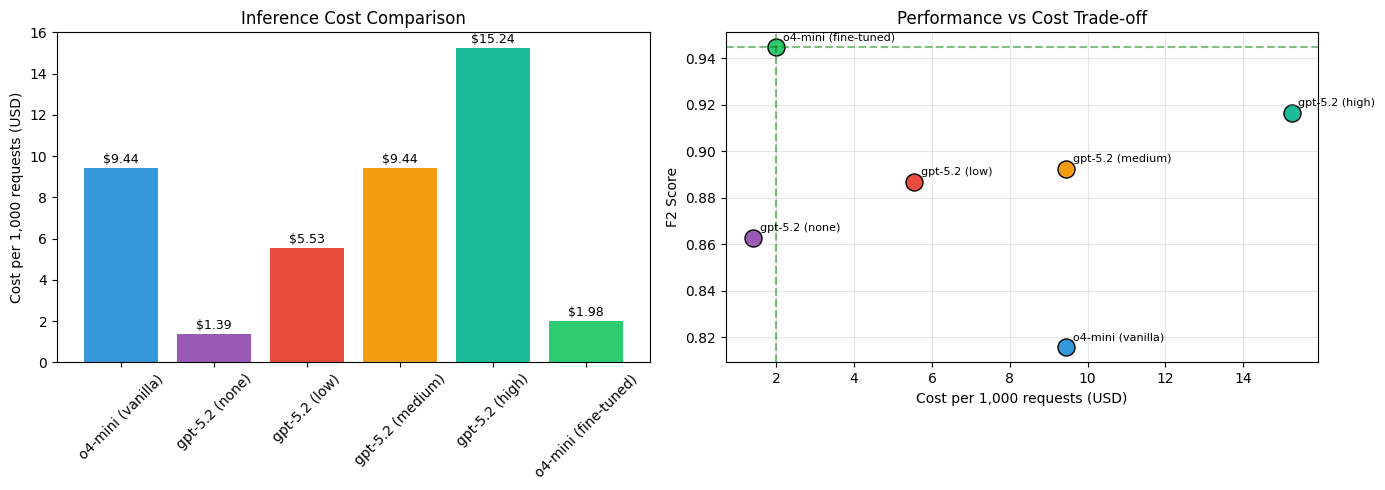


📊 Saved: c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\planner\cost_analysis.png


In [12]:
from utils import plot_cost_vs_performance

plot_cost_vs_performance(
    f2_scores,
    cost_results,
    PLANNER_OUTPUTS_DIR / 'cost_analysis.png'
)

---

## Latency Analysis

RFT doesn't just improve quality — it also reduces latency. The fine-tuned model was trained with `reasoning_effort="low"`, learning to reason more efficiently. At inference, we evaluate it at `low` (matching training), while o4-mini vanilla uses the default (`medium`).

**Key insight:** RFT teaches the model to produce correct tool selections with fewer reasoning tokens, directly reducing response time.

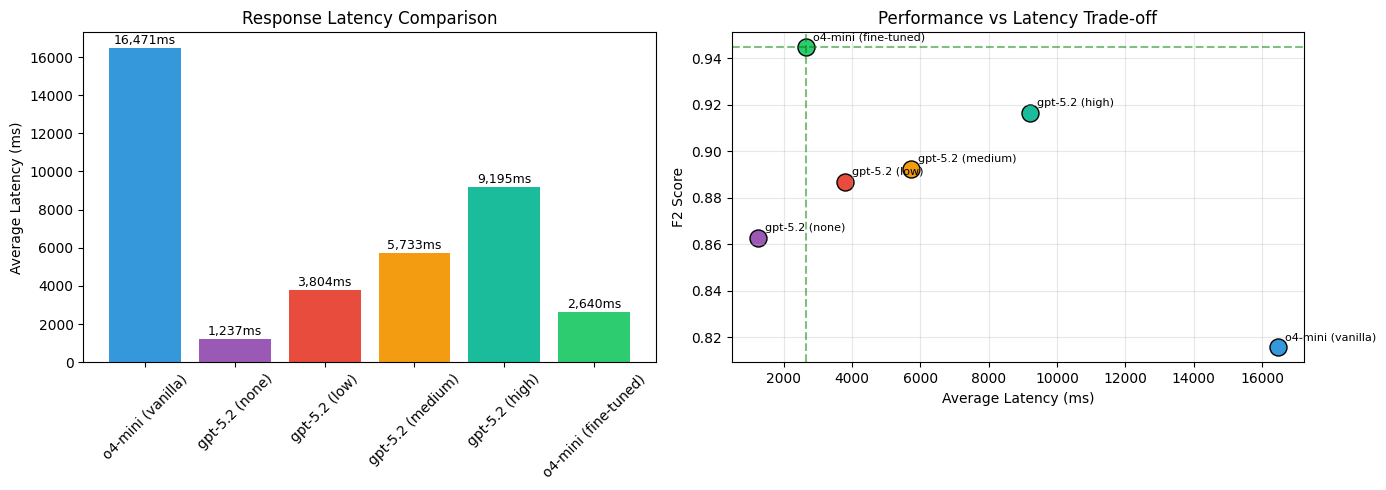


📊 Saved: c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\planner\latency_analysis.png


In [13]:
from utils import plot_latency_analysis

plot_latency_analysis(
    f2_scores,
    usage_data,
    PLANNER_OUTPUTS_DIR / 'latency_analysis.png'
)

---

## Summary

In [14]:
from IPython.display import display, Markdown
from utils import build_summary_table

model_configs = {
    "o4-mini (vanilla)": AZURE_DEPLOYMENT,
    "gpt-5.2 (none)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: none)",
    "gpt-5.2 (low)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: low)",
    "gpt-5.2 (medium)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: medium)",
    "gpt-5.2 (high)": f"{AZURE_DEPLOYMENT_VANILLA} (reasoning: high)",
    "o4-mini (fine-tuned)": FINETUNED_DEPLOYMENT
}

display(Markdown(build_summary_table(f2_scores, model_configs, len(eval_samples))))

### 🏆 EVALUATION COMPLETE

| Config | Model |
|--------|-------|
| o4-mini (vanilla) | o4-mini |
| gpt-5.2 (none) | gpt-5.2 (reasoning: none) |
| gpt-5.2 (low) | gpt-5.2 (reasoning: low) |
| gpt-5.2 (medium) | gpt-5.2 (reasoning: medium) |
| gpt-5.2 (high) | gpt-5.2 (reasoning: high) |
| o4-mini (fine-tuned) | planner-low-0128-1740-step60 |

**Samples:** 30

**F2 Scores (vs o4-mini vanilla):**
| Model | F2 Score | Delta |
|-------|----------|-------|
| o4-mini (vanilla) | 0.816 | +0.0% |
| gpt-5.2 (none) | 0.863 | +5.8% |
| gpt-5.2 (low) | 0.887 | +8.7% |
| gpt-5.2 (medium) | 0.892 | +9.4% |
| gpt-5.2 (high) | 0.917 | +12.4% |
| o4-mini (fine-tuned) | 0.945 | +15.8% |

🎉 **o4-mini (fine-tuned) wins!** RFT provides value even vs larger models with reasoning.

🚀 Run `05_multiagent_with_tool_calling.ipynb` to test the multi-agent workflow!